# Trabajo Práctico N°1
## Problema 1: Clasificación Binaria

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

Construir un modelo de red neuronal que prediga si un paciente tiene alto riesgo de padecer un accidente cerebrovascular (ACV) o no, a partir de sus datos clínicos y demográficos.

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [173]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [174]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [176]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


###  Análisis Exploratorio de Datos (EDA)

**División cruzada train - test**

In [177]:
X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 4088
Test size: 1022


**Visualización de datos** (previo a la imputación)

In [178]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

show_num = X_train[numerical_cols].copy()
show_num['stroke'] = y_train.values

C:\Users\juana\AppData\Local\Temp\ipykernel_16628\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\3058852136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


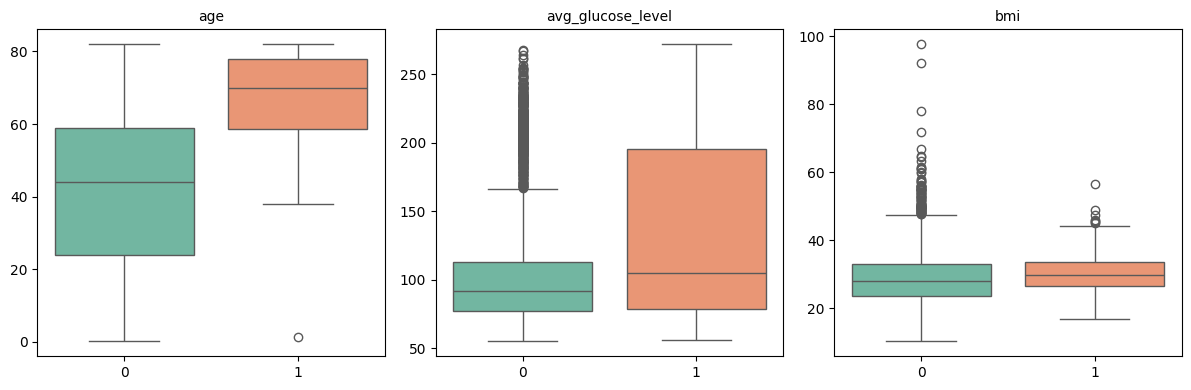

In [179]:
cols = 4
num_vars = len(show_num.columns) - 1 
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show_num.columns[:-1]): 
    sns.boxplot(
        data=show_num,
        x='stroke',
        y=var, 
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

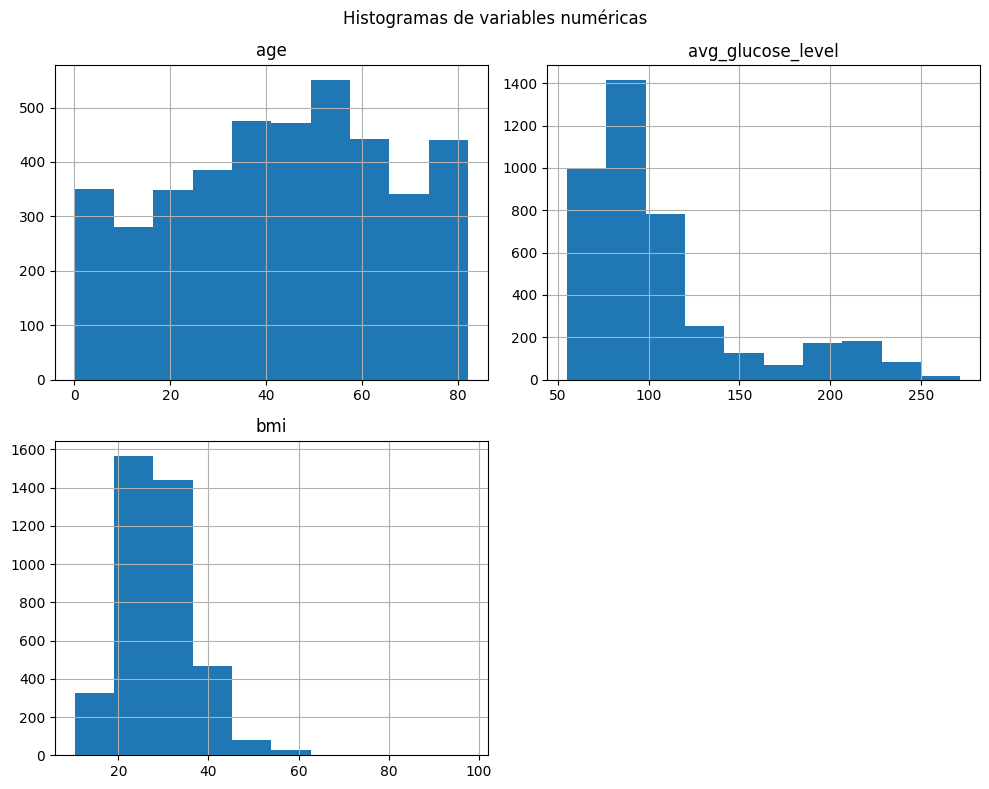

In [180]:
show_num[['age', 'avg_glucose_level', 'bmi']].hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

C:\Users\juana\AppData\Local\Temp\ipykernel_16628\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\863497507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
C:\Users\juan

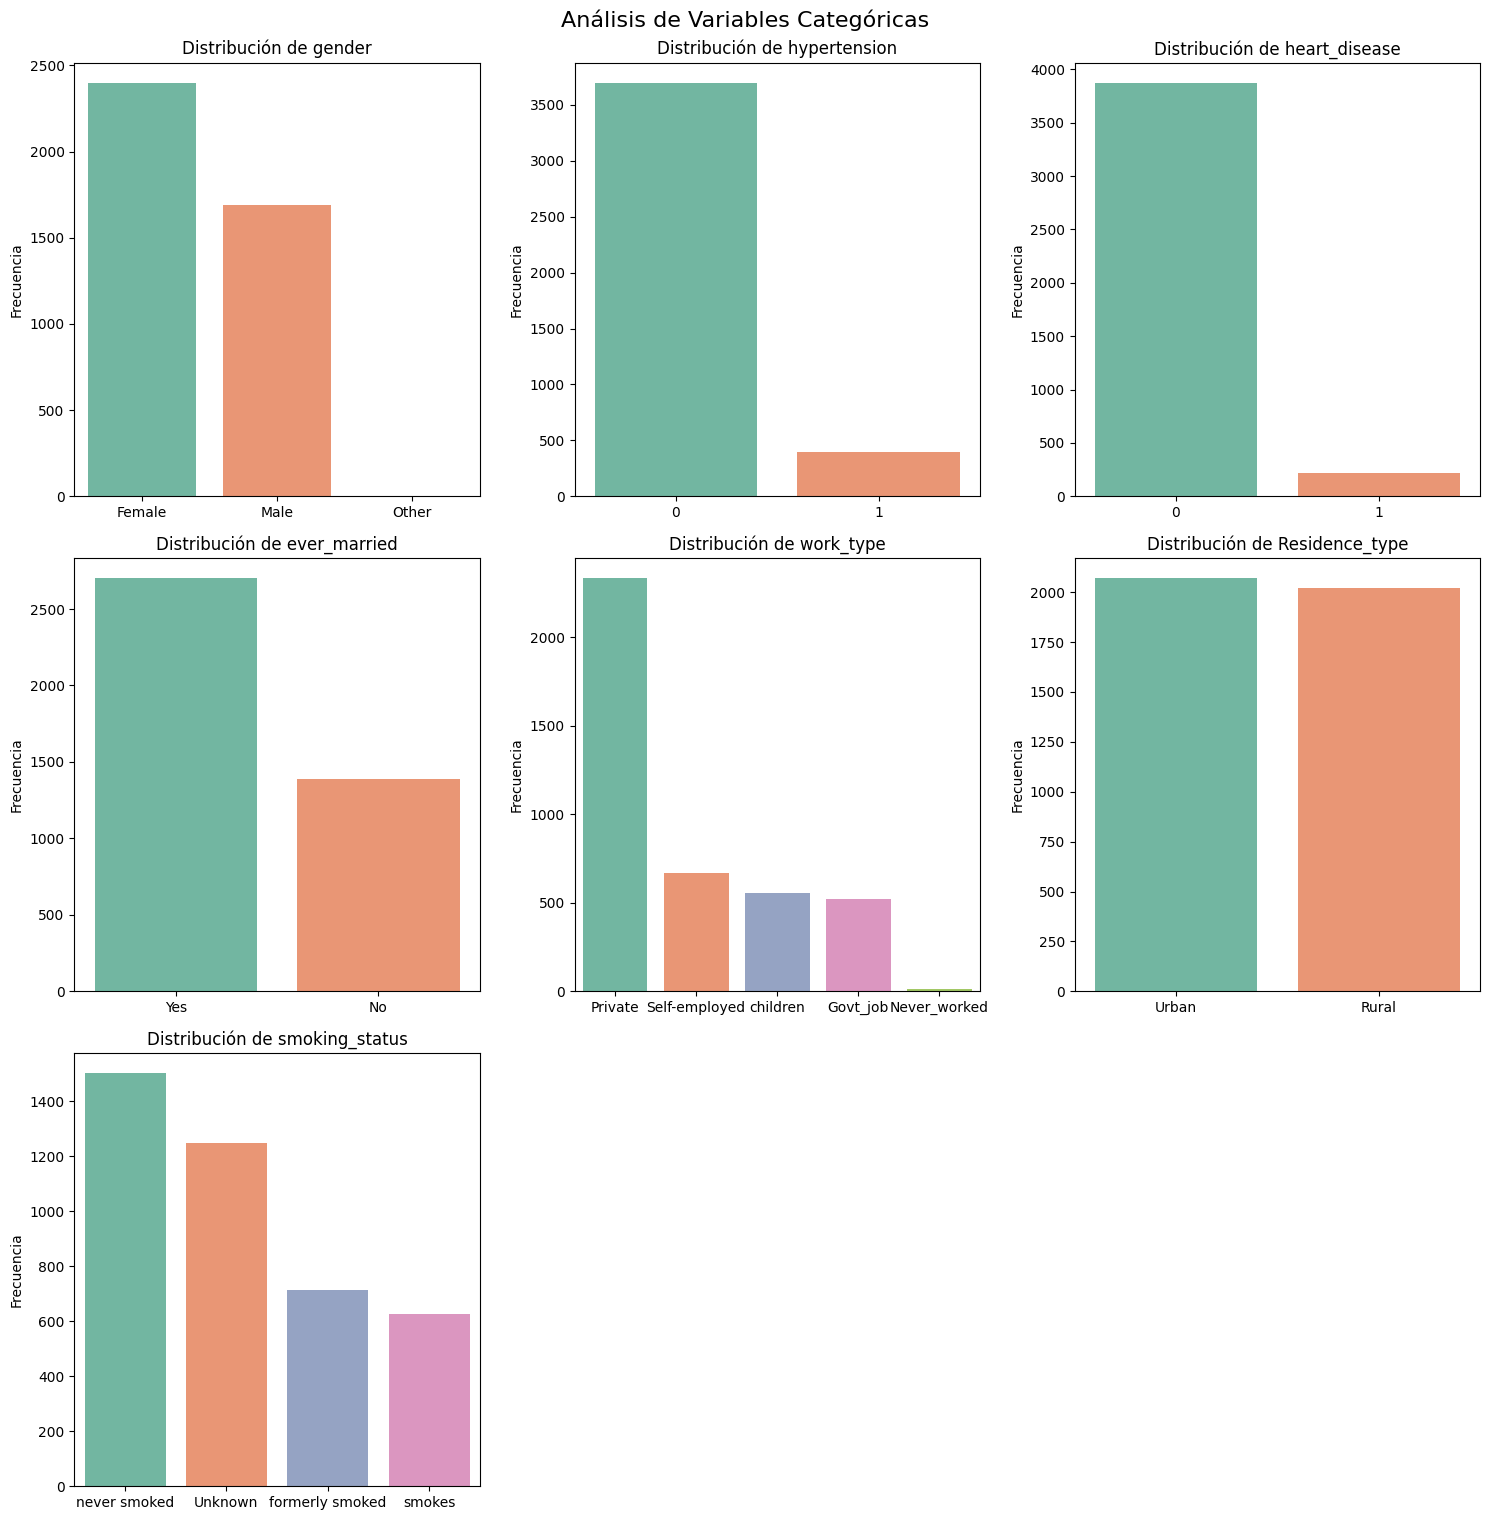

In [181]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']

show_cat = X_train[categorical_cols].copy()
show_cat['stroke'] = y_train.values

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = show_cat[col].value_counts().index
    sns.countplot(data=show_cat, x=col, ax=axes[i], palette='Set2', order=order)
    
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Análisis de Variables Categóricas", fontsize=16, y=1.01)
plt.show()

**Análisis y decisión sobre datos faltantes y outliers**

In [182]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

filas_antes_train = len(train)
filas_antes_test = len(test)

In [183]:
train.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  170
smoking_status         0
stroke                 0
dtype: int64

In [184]:
test.isna().sum()

id                    0
gender                0
age                   0
hypertension          0
heart_disease         0
ever_married          0
work_type             0
Residence_type        0
avg_glucose_level     0
bmi                  31
smoking_status        0
stroke                0
dtype: int64

hacer limpieza

In [185]:
# Outliers

limite_bmi = 80 # valores por encima de este limite se consideran outliers
train.loc[train['bmi'] > limite_bmi, 'bmi'] = np.nan

REVISAR

Contexto Médico: En medicina, un BMI > 60 se considera "Súper-Súper Obesidad". Son casos donde la fisiología cambia drásticamente y podrían actuar como ruido para la Red Neuronal, pero mantenés a todos los pacientes con obesidad "estándar" y "mórbida" (BMI 30-50) que son vitales para predecir un ACV.

Simplicidad: Es más fácil de explicar en tu informe del TP: "Se decidió filtrar solo valores superiores a 60 para eliminar ruido extremo sin perder la representatividad de pacientes obesos".

In [186]:
# imputar (solo bmi)

In [187]:
filas_despues_train = len(train)
print('Cantidad total de filas eliminadas de train: ', filas_antes_train - filas_despues_train)

filas_despues_test = len(test)
print('Cantidad total de filas eliminadas de test: ', filas_antes_test - filas_despues_test)

Cantidad total de filas eliminadas de train:  0
Cantidad total de filas eliminadas de test:  0


**División y elección de variables importantes**

In [188]:
X_train = train.drop(columns=['stroke']).reset_index(drop=True)
X_test  = test.drop(columns=['stroke']).reset_index(drop=True)
y_train = train['stroke'].reset_index(drop=True)
y_test  = test['stroke'].reset_index(drop=True)

# fijarse esto
cols = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status']

X_train = X_train[cols]
X_test  = X_test[cols]

**Codificación de variables categóricas**

In [189]:
X_all = pd.concat([X_train, X_test], axis=0)
X_all = pd.get_dummies(X_all, drop_first=True)

X_train = X_all.iloc[:len(X_train), :].reset_index(drop=True)
X_test  = X_all.iloc[len(X_train): , :].reset_index(drop=True)

**Visualización de datos** (posterior a la imputación)

In [190]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

show_num = X_train[numerical_cols].copy()
show_num['stroke'] = y_train.values

C:\Users\juana\AppData\Local\Temp\ipykernel_16628\2970029014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\2970029014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juana\AppData\Local\Temp\ipykernel_16628\2970029014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


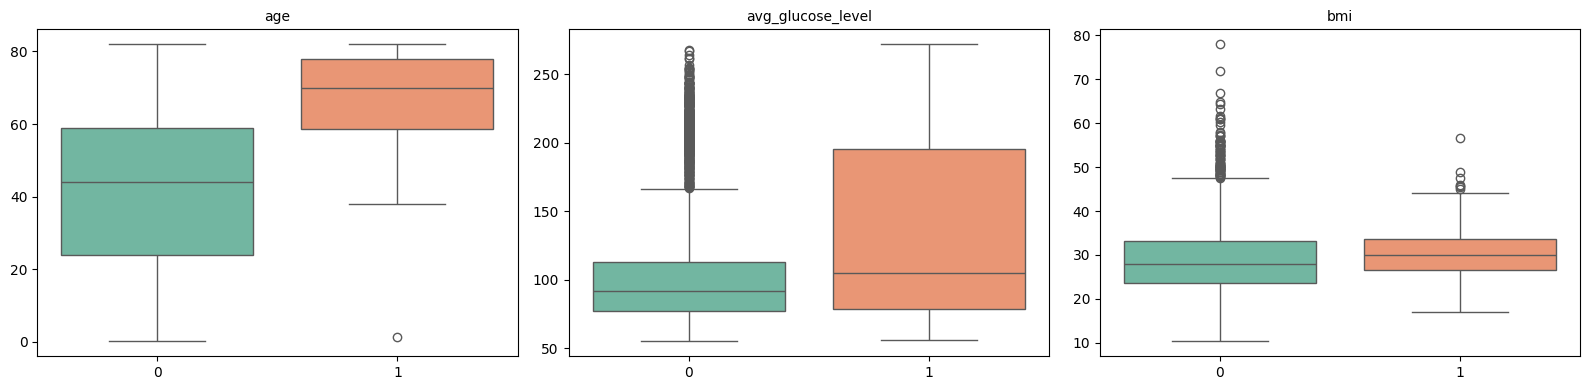

In [191]:
cols = 3
num_vars = len(show.columns) - 1
rows = (num_vars + cols - 1) // cols

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, var in enumerate(show.columns[:-1]): 
    sns.boxplot(
        data=show_num,
        x='stroke', 
        y=var,
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

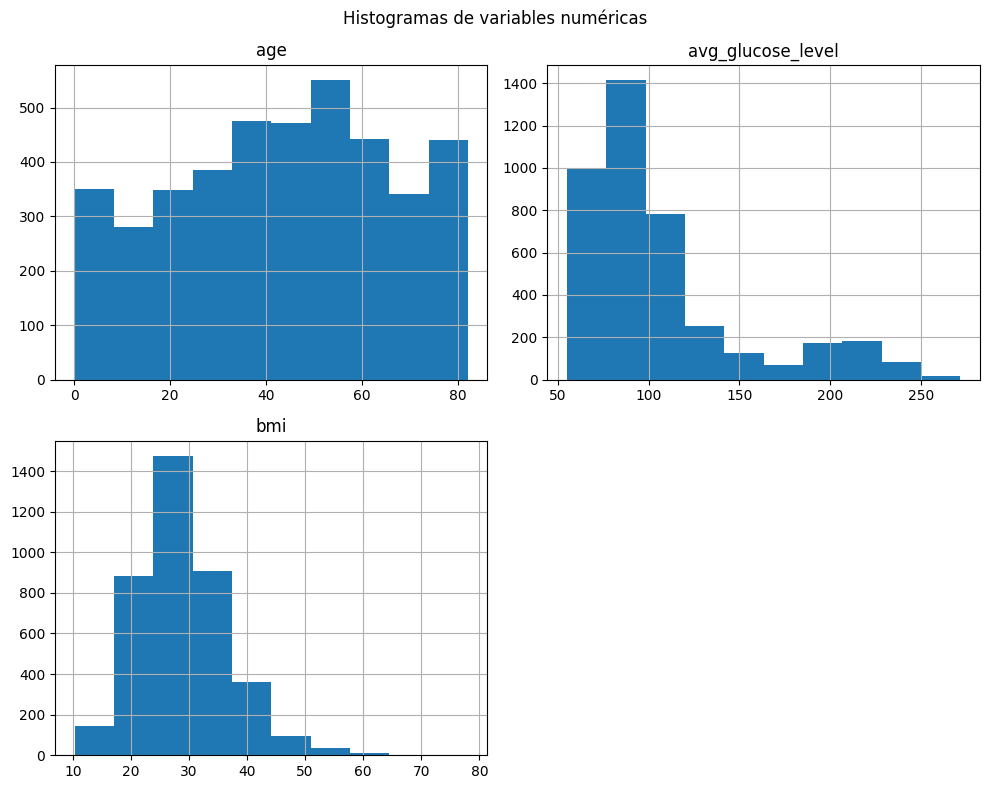

In [192]:
show_num.drop(columns='stroke', inplace=True)

show_num.hist(figsize=(10,8))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

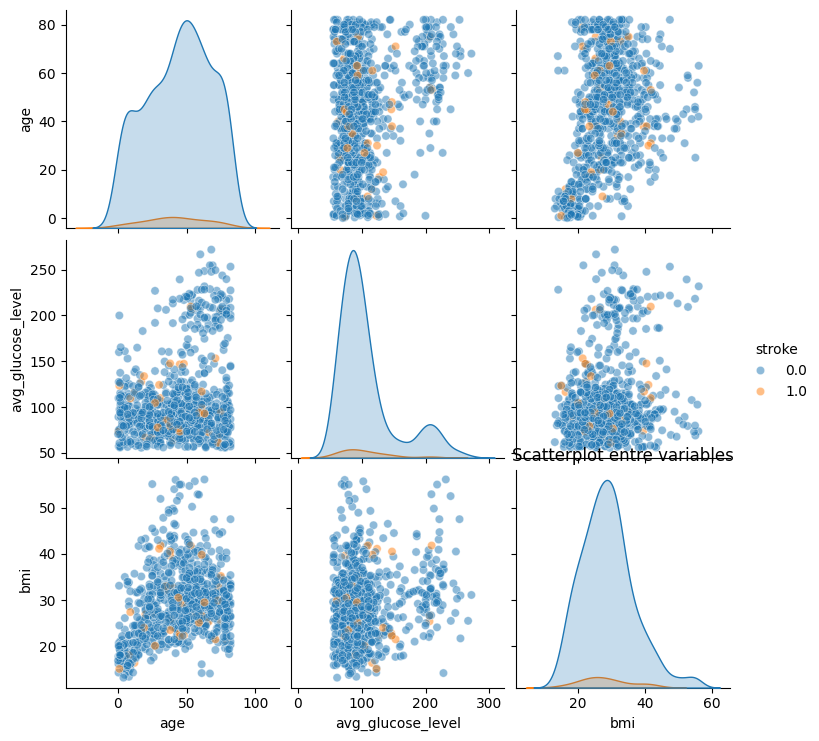

In [193]:
pshow = show.copy()
pshow['stroke'] = y_train
sns.pairplot(pshow.sample(1000, random_state=1), hue='stroke', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.title('Scatterplot entre variables')
plt.show()

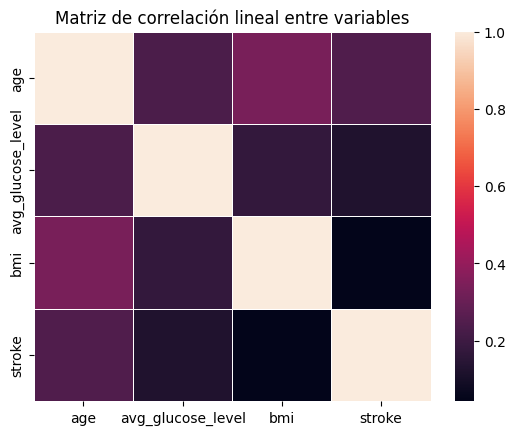

In [194]:
corrmat = show.corr()
sns.heatmap(corrmat, vmax=1, linewidths=.5)
plt.title('Matriz de correlación lineal entre variables')
plt.show()

In [195]:
def relacion(X_train, y_train):
    resultados = []

    for col in X_train.columns:
        corr, _ = pointbiserialr(X_train[col], y_train)
        resultados.append({'Variable': col, 'Relacion': corr})
    
    return pd.DataFrame(resultados).sort_values(by='Relacion', ascending=False)

df_corr = relacion(X_train, y_train)
df_corr = df_corr.set_index("Variable")

plt.figure(figsize=(len(df_corr)*0.5, 3))
sns.heatmap(
    df_corr[["Relacion"]].T,
    annot=True,
    cmap="coolwarm",
    center=0,
    annot_kws={"rotation": 90, "va": "center", "ha": "center"}
)
plt.title("Relación (Point-Biserial) entre cada variable y la clase")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

ValueError: array must not contain infs or NaNs

**Estandarización/escalado de datos.**

In [ ]:
#Estandarizamos las columnas (ya son todas numéricas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Análisis del balance de clases**

In [ ]:
train_counts = y_train.value_counts().rename("Cantidad_train")
train_perc = (y_train.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_train")

test_counts = y_test.value_counts().rename("Cantidad_test")
test_perc = (y_test.value_counts(normalize=True) * 100).round(2).rename("Porcentaje_test")

tabla_balance = pd.concat([train_counts, train_perc, test_counts, test_perc], axis=1)
tabla_balance.index.name = "Clase"
display(tabla_balance)

,Cantidad_train,Porcentaje_train,Cantidad_test,Porcentaje_test
Clase,,,,
0,3889,95.13,972,95.11
1,199,4.87,50,4.89


ver que hacemos

### Implementación de la Red Neuronal

### Entrenamiento y curva de aprendizaje

### Evaluación del modelo

### Matriz de confusión

### Análisis y conclusiones